In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import re
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

import transformers

from sklearn.metrics import classification_report

In [2]:
# load data
x_train = torch.load("data/test_embeddings/x_train")
x_val = torch.load("data/test_embeddings/x_val")
x_test = torch.load("data/test_embeddings/x_test")
y_train = torch.load("data/test_embeddings/y_train")
y_val = torch.load("data/test_embeddings/y_val")
y_test = torch.load("data/test_embeddings/y_test")
# 🔧 Fix: fix label dtype
y_train = y_train.float()
y_val   = y_val.float()
y_test  = y_test.float()

In [3]:
class KimCNN(nn.Module):
    """
    CNN for binary classification of BERT-embedding sentences
    """
    def __init__(self, embed_num, embed_dim, class_num, kernel_num, kernel_sizes, dropout, static):
        super(KimCNN, self).__init__()
        V = embed_num
        D = embed_dim
        C = class_num
        Co = kernel_num
        Ks = kernel_sizes
        
        self.static = static
        self.convs1 = nn.ModuleList([nn.Conv2d(1, Co, (K, D)) for K in Ks])
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(len(Ks) * Co, C)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = x.unsqueeze(1)  # (N, 1, seq_len, 768)
        x = [F.relu(conv(x)).squeeze(3) for conv in self.convs1]
        x = [F.max_pool1d(i, i.size(2)).squeeze(2) for i in x]
        x = torch.cat(x, 1)
        x = self.dropout(x)
        x = self.fc1(x)
        return torch.sigmoid(x)


In [4]:
# hyperparameters
embed_num = x_train.shape[1]   # sequence length
embed_dim = x_train.shape[2]   # 768
class_num = 1                  # binary classification 
kernel_num = 3 
kernel_sizes = [2, 3, 4] 
dropout = 0.1 
static = True

model = KimCNN(
    embed_num=embed_num,
    embed_dim=embed_dim,
    class_num=class_num,
    kernel_num=kernel_num,
    kernel_sizes=kernel_sizes,
    dropout=dropout,
    static=static,
)

n_epochs = 10 
lr = 0.0001 
batch_size = 10
optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
loss_fn = nn.BCELoss() 

In [5]:
def generate_batch_data(x, y, batch_size):
    i, batch = 0, 0
    for batch, i in enumerate(range(0, len(x) - batch_size, batch_size), 1):
        x_batch = x[i : i + batch_size]
        y_batch = y[i : i + batch_size]
        yield x_batch, y_batch, batch
    if i + batch_size < len(x):
        yield x[i + batch_size :], y[i + batch_size :], batch + 1
    if batch == 0:
        yield x, y, 1

In [6]:
train_losses, val_losses = [], []
for epoch in range(n_epochs):
    start_time = time.time()
    train_loss = 0
    model.train(True)
    for x_batch, y_batch, batch in generate_batch_data(x_train, y_train, batch_size):
        y_pred = model(x_batch)
        optimizer.zero_grad()
        loss = loss_fn(y_pred.squeeze(1), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()


    train_loss /= batch
    train_losses.append(train_loss)
    elapsed = time.time() - start_time
    
    model.eval() 
    with torch.no_grad(): 
        val_loss, batch = 0, 1
        for x_batch, y_batch, batch in generate_batch_data(x_val, y_val, batch_size):
            y_pred = model(x_batch)
            loss = loss_fn(y_pred.squeeze(1), y_batch)
            val_loss += loss.item()

    val_loss /= batch
    val_losses.append(val_loss)
    print("Epoch %d Train loss: %.2f. Validation loss: %.2f. Elapsed time: %.2fs."
        % (epoch + 1, train_losses[-1], val_losses[-1], elapsed))

Epoch 1 Train loss: 0.71. Validation loss: 0.69. Elapsed time: 0.69s.
Epoch 2 Train loss: 0.68. Validation loss: 0.69. Elapsed time: 0.47s.
Epoch 3 Train loss: 0.68. Validation loss: 0.69. Elapsed time: 0.46s.
Epoch 4 Train loss: 0.67. Validation loss: 0.69. Elapsed time: 0.45s.
Epoch 5 Train loss: 0.66. Validation loss: 0.69. Elapsed time: 0.45s.
Epoch 6 Train loss: 0.65. Validation loss: 0.69. Elapsed time: 0.45s.
Epoch 7 Train loss: 0.65. Validation loss: 0.69. Elapsed time: 0.46s.
Epoch 8 Train loss: 0.64. Validation loss: 0.68. Elapsed time: 0.45s.
Epoch 9 Train loss: 0.63. Validation loss: 0.68. Elapsed time: 0.45s.
Epoch 10 Train loss: 0.61. Validation loss: 0.68. Elapsed time: 0.45s.


Text(0.5, 1.0, 'Losses')

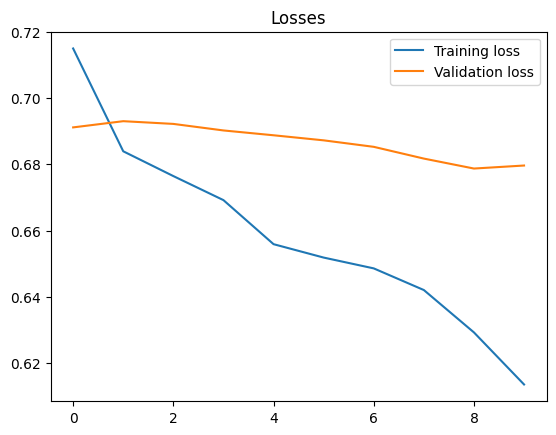

In [7]:
# plot losses
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.legend()
plt.title("Losses")

In [8]:
# evaluate predictions
model.eval()

with torch.no_grad():
    y_pred = model(x_test)

# convert to numpy + binary
y_pred_np = (y_pred.squeeze().cpu().numpy() > 0.5).astype(int)
y_test_np = y_test.squeeze().cpu().numpy().astype(int)

print(classification_report(y_test_np, y_pred_np))


              precision    recall  f1-score   support

           0       0.67      0.80      0.73         5
           1       0.75      0.60      0.67         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10

